In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
raw_data = pd.read_csv("training_dataset_filtered.csv")

In [29]:
raw_data.head()

,year,semester,campus,course_code,course_prefix,is_core,is_math,avg_fail_ratio_3y,recent_fail_count,is_offered_last_year,latent_demand_count,bottleneck_score,plan_alignment_score,course_level,gap_since_last_offered,is_offered
0,2020,Fall,Beirut,CSC201,CSC,1,0,0.0,0,0,0,0,1.0,2,99,1
1,2020,Fall,Beirut,CSC243,CSC,1,0,0.0,0,0,0,1,1.0,2,99,1
2,2020,Fall,Beirut,CSC245,CSC,1,0,0.0,0,0,0,4,0.0,2,99,1
3,2020,Fall,Beirut,CSC310,CSC,1,0,0.0,0,0,0,6,1.0,3,99,1
4,2020,Fall,Beirut,CSC317,CSC,0,0,0.0,0,0,0,0,1.0,3,99,0


In [30]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3164 entries, 0 to 3163
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    3164 non-null   int64  
 1   semester                3164 non-null   object 
 2   campus                  3164 non-null   object 
 3   course_code             3164 non-null   object 
 4   course_prefix           3164 non-null   object 
 5   is_core                 3164 non-null   int64  
 6   is_math                 3164 non-null   int64  
 7   avg_fail_ratio_3y       3164 non-null   float64
 8   recent_fail_count       3164 non-null   int64  
 9   is_offered_last_year    3164 non-null   int64  
 10  latent_demand_count     3164 non-null   int64  
 11  bottleneck_score        3164 non-null   int64  
 12  plan_alignment_score    3164 non-null   float64
 13  course_level            3164 non-null   int64  
 14  gap_since_last_offered  3164 non-null   

In [31]:
raw_data.describe().T

,count,mean,std,min,25%,50%,75%,max
year,3164.0,2022.500000,1.401751,2020.0,2021.0,2022.5,2024.00000,2025.0
is_core,3164.0,0.230088,0.420956,0.0,0.0,0.0,0.00000,1.0
is_math,3164.0,0.221239,0.415147,0.0,0.0,0.0,0.00000,1.0
avg_fail_ratio_3y,3164.0,0.029707,0.063162,0.0,0.0,0.0,0.03325,1.0
recent_fail_count,3164.0,1.359987,4.712103,0.0,0.0,0.0,0.00000,106.0
is_offered_last_year,3164.0,0.212705,0.409286,0.0,0.0,0.0,0.00000,1.0
latent_demand_count,3164.0,22.726296,53.672674,0.0,0.0,0.0,15.00000,427.0
bottleneck_score,3164.0,0.566372,1.579294,0.0,0.0,0.0,0.00000,9.0
plan_alignment_score,3164.0,0.789507,0.407723,0.0,1.0,1.0,1.00000,1.0
course_level,3164.0,4.292035,1.473784,1.0,3.0,4.0,6.00000,6.0


In [32]:
raw_data.drop_duplicates(inplace=True)
raw_data.dropna(inplace=True)
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3164 entries, 0 to 3163
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    3164 non-null   int64  
 1   semester                3164 non-null   object 
 2   campus                  3164 non-null   object 
 3   course_code             3164 non-null   object 
 4   course_prefix           3164 non-null   object 
 5   is_core                 3164 non-null   int64  
 6   is_math                 3164 non-null   int64  
 7   avg_fail_ratio_3y       3164 non-null   float64
 8   recent_fail_count       3164 non-null   int64  
 9   is_offered_last_year    3164 non-null   int64  
 10  latent_demand_count     3164 non-null   int64  
 11  bottleneck_score        3164 non-null   int64  
 12  plan_alignment_score    3164 non-null   float64
 13  course_level            3164 non-null   int64  
 14  gap_since_last_offered  3164 non-null   

In [33]:
#sns.pairplot(raw_data, hue="is_offered")
#plt.show()

# Task
Build a machine learning ensemble to predict course offerings using the data from "/content/training_dataset_filtered.csv".

1. **Data Preprocessing**: Encode categorical variables (`semester`, `campus`, `course_prefix`), drop non-predictive columns such as `course_code`, and split the dataset into training and testing sets (80/20 split).
2. **Model Tuning**: Perform hyperparameter tuning using `GridSearchCV` with 5-fold cross-validation for both a Random Forest classifier and an XGBoost classifier to optimize performance.
3. **Ensemble Construction**: Create a `VotingClassifier` using soft voting to combine the best-tuned Random Forest and XGBoost models.
4. **Evaluation**: Assess the ensemble model's performance on the test set by generating a classification report, a Confusion Matrix heatmap, and an ROC-AUC curve (including all necessary titles and legends).
5. **Feature Importance**: Extract and visualize feature importance rankings to identify key predictors.
6. **Final Assessment**: Summarize the model's predictive capabilities and key findings from the analysis.

## Preprocess Data

### Subtask:
Prepare the dataset for modeling by encoding categorical variables, removing non-predictive columns, and splitting into training and testing sets.


**Reasoning**:
I will perform data preprocessing including one-hot encoding for categorical variables, dropping non-predictive columns, and splitting the dataset into training and testing sets as per the instructions.



In [58]:
from sklearn.model_selection import train_test_split
campus = 0 # 0 is Beirut, 1 is Byblos

# 1. One-hot encoding categorical columns
encoded_df = pd.get_dummies(raw_data, columns=['semester'])

# CAMPUS FILTERING
# Initially default campus
# Change according to selected one on website
# Parameter passed to this code, will choose model to predict on
# Retraining: will filter dataset accordingly, train, and output model with appropriate name for backend
if campus == 0:
  encoded_df = encoded_df[encoded_df['campus']=='Beirut'].drop(columns=['campus'])
else:
  encoded_df = encoded_df[encoded_df['campus']=='Byblos'].drop(columns=['campus'])

# 2. Identify target and drop non-predictive column 'course_code'
# We use the encoded dataframe for X
y = encoded_df['is_offered']
X = encoded_df.drop(columns=['is_offered', 'course_code', 'course_prefix'])

# 5. Split the data into training and testing sets (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Verify the shapes
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (1265, 14)
X_test shape: (317, 14)
y_train shape: (1265,)
y_test shape: (317,)


In [35]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1582 entries, 113 to 3163
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    1582 non-null   int64  
 1   course_code             1582 non-null   object 
 2   course_prefix           1582 non-null   object 
 3   is_core                 1582 non-null   int64  
 4   is_math                 1582 non-null   int64  
 5   avg_fail_ratio_3y       1582 non-null   float64
 6   recent_fail_count       1582 non-null   int64  
 7   is_offered_last_year    1582 non-null   int64  
 8   latent_demand_count     1582 non-null   int64  
 9   bottleneck_score        1582 non-null   int64  
 10  plan_alignment_score    1582 non-null   float64
 11  course_level            1582 non-null   int64  
 12  gap_since_last_offered  1582 non-null   int64  
 13  is_offered              1582 non-null   int64  
 14  semester_Fall           1582 non-null   boo

## Tune Random Forest

### Subtask:
Initialize a Random Forest classifier and use GridSearchCV to find the optimal hyperparameters using 5-fold cross-validation.


**Reasoning**:
I will initialize the Random Forest classifier, define the hyperparameter grid, and use GridSearchCV with 5-fold cross-validation to find and store the best model parameters as requested.



In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'random_state': [42]
}

# 2. Instantiate the classifier
rf = RandomForestClassifier(random_state=42)

# 3. Set up GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# 4. Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

# 5. Identify and store the best estimator
best_rf_model = grid_search_rf.best_estimator_

print(f"Best Random Forest Parameters: {grid_search_rf.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid_search_rf.best_score_:.4f}")

Best Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200, 'random_state': 42}
Best Cross-Validation F1 Score: 0.8264


## Tune XGBoost

### Subtask:
Initialize an XGBoost classifier and perform hyperparameter tuning using GridSearchCV to optimize learning rate, max depth, and number of estimators.


**Reasoning**:
I will initialize the XGBoost classifier, define the hyperparameter grid, and use GridSearchCV with 5-fold cross-validation to find and store the best XGBoost model as specified in the subtask instructions.



In [37]:
from xgboost import XGBClassifier

# 1. Define the parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [None, 3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'random_state': [42]
}

# 2. Instantiate the XGBClassifier (removed deprecated use_label_encoder)
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

# 3. Set up GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# 4. Fit GridSearchCV to the training data
grid_search_xgb.fit(X_train, y_train)

# 5. Identify and store the best estimator
best_xgb_model = grid_search_xgb.best_estimator_

print(f"Best XGBoost Parameters: {grid_search_xgb.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid_search_xgb.best_score_:.4f}")

Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'random_state': 42}
Best Cross-Validation F1 Score: 0.8076


## Create Voting Classifier Ensemble

### Subtask:
Combine the best-tuned Random Forest and XGBoost models into a Voting Classifier (soft voting) to leverage the strengths of both algorithms.


**Reasoning**:
I will initialize the VotingClassifier using the best-tuned Random Forest and XGBoost models, configure it for soft voting, and fit it to the training data as instructed.



In [38]:
from sklearn.ensemble import VotingClassifier

# 1. Define the estimators using the best-tuned models
estimators = [
    ('rf', best_rf_model),
    ('xgb', best_xgb_model)
]

# 2. Instantiate the VotingClassifier with soft voting
ensemble_model = VotingClassifier(estimators=estimators, voting='soft')

# 3. Fit the ensemble model to the training data
ensemble_model.fit(X_train, y_train)

print("Voting Classifier Ensemble (soft voting) has been successfully created and fitted.")

Voting Classifier Ensemble (soft voting) has been successfully created and fitted.


## Evaluate Model Performance

### Subtask:
Evaluate the ensemble model on the test set by generating a classification report, a Confusion Matrix heatmap, and an ROC-AUC curve.


**Reasoning**:
I will evaluate the performance of the ensemble model by generating a classification report, a confusion matrix heatmap, and an ROC-AUC curve as specified in the instructions.



Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       246
           1       0.84      0.79      0.81        71

    accuracy                           0.92       317
   macro avg       0.89      0.87      0.88       317
weighted avg       0.92      0.92      0.92       317



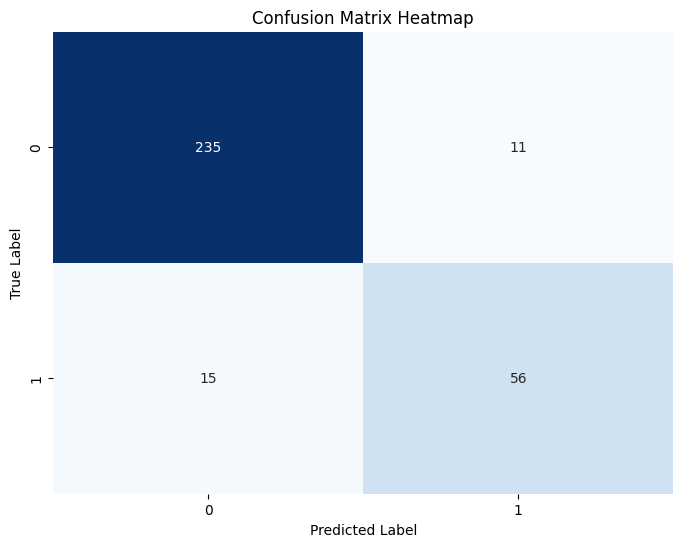

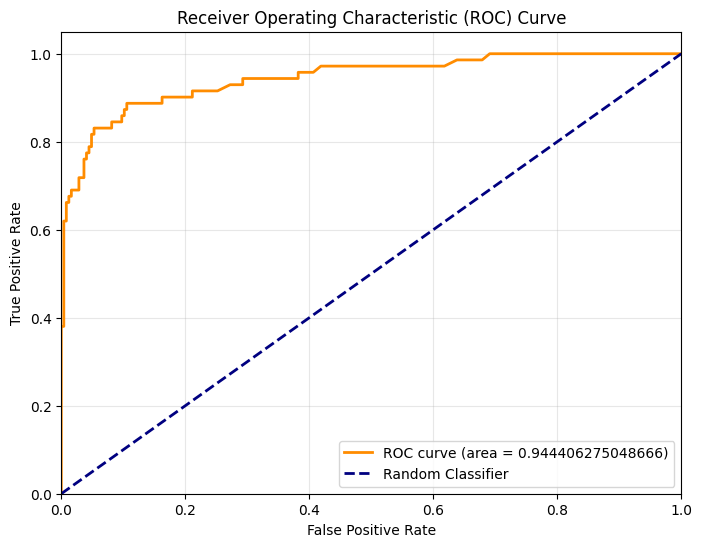

In [55]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

# 1. Generate predictions and probabilities
y_probs = ensemble_model.predict_proba(X_test)[:, 1]
threshold = 0.4
y_pred = (y_probs >= threshold).astype(int)

# 2. Print Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 3. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

# 4. ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       983
           1       0.88      0.87      0.87       282

    accuracy                           0.94      1265
   macro avg       0.92      0.92      0.92      1265
weighted avg       0.94      0.94      0.94      1265



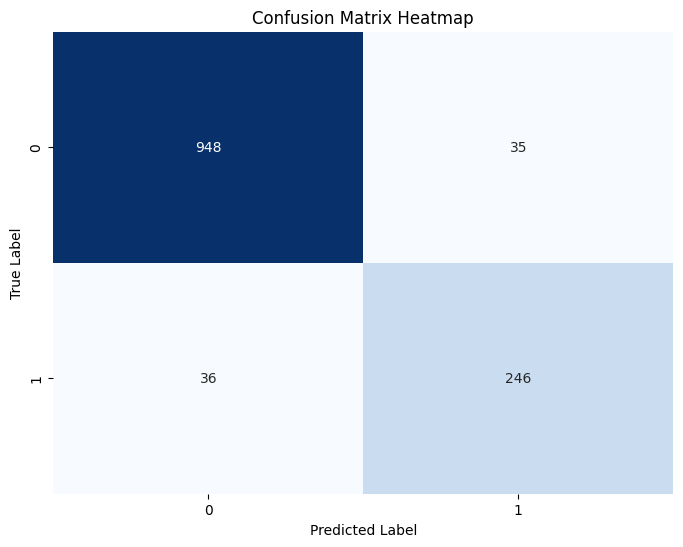

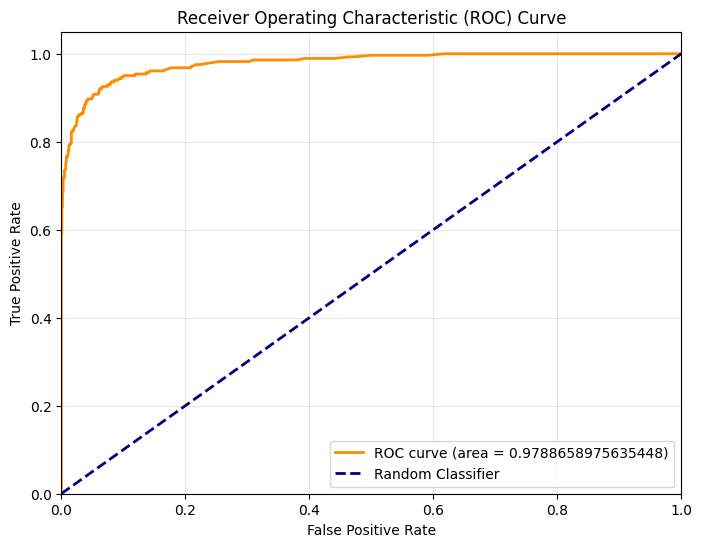

In [56]:
# 1. Generate predictions and probabilities (TRAIN)
y_probs_train = ensemble_model.predict_proba(X_train)[:, 1]
threshold = 0.4
y_pred_train = (y_probs_train >= threshold).astype(int)

# 2. Print Classification Report
print("Classification Report:")
print(classification_report(y_train, y_pred_train))

# 3. Confusion Matrix Heatmap
cm = confusion_matrix(y_train, y_pred_train)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

# 4. ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_train, y_probs_train)
auc_score = roc_auc_score(y_train, y_probs_train)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Feature Importance Analysis

### Subtask:
Extract and visualize the feature importance rankings from the models to identify the key predictors for course offerings.


**Reasoning**:
I will extract the feature importance from the best Random Forest and XGBoost models, aggregate them into a DataFrame, calculate the average importance, and visualize the results using a horizontal bar plot as instructed.



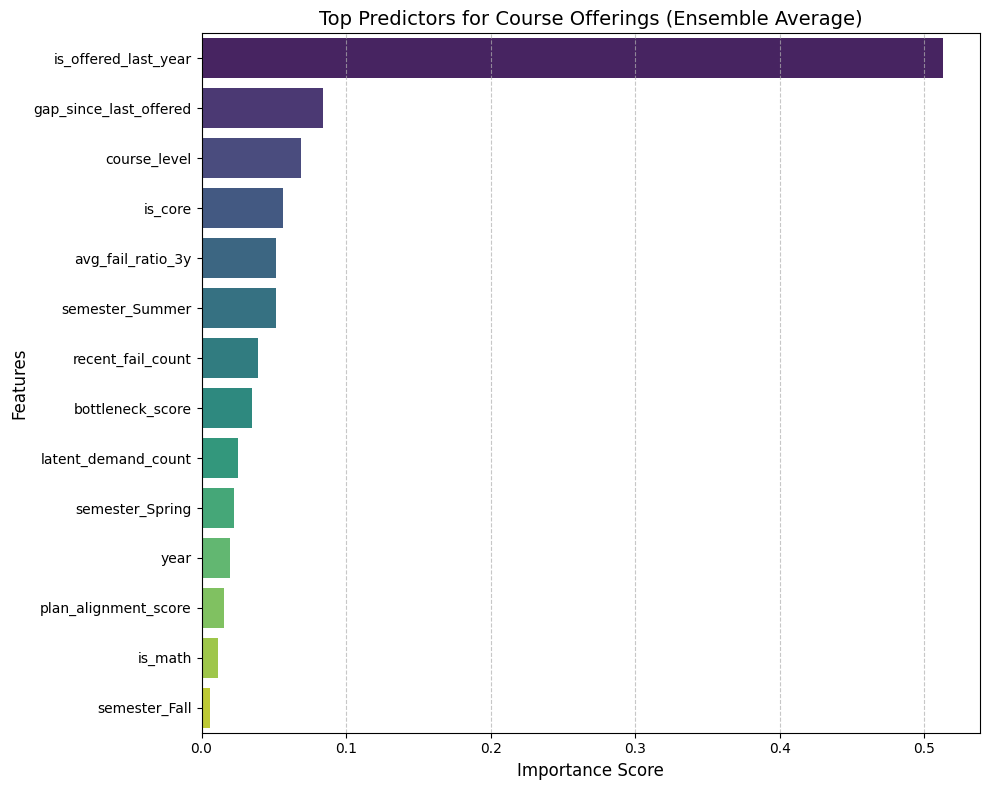

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract importance from both models
rf_importance = best_rf_model.feature_importances_
xgb_importance = best_xgb_model.feature_importances_

# 2. Create a DataFrame to aggregate scores
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'RandomForest': rf_importance,
    'XGBoost': xgb_importance
})

# 3. Calculate average importance and sort
feature_importance_df['Average_Importance'] = feature_importance_df[['RandomForest', 'XGBoost']].mean(axis=1)
feature_importance_df = feature_importance_df.sort_values(by='Average_Importance', ascending=False)

# 4. Create horizontal bar plot with updated seaborn parameters to avoid FutureWarning
plt.figure(figsize=(10, 8))
sns.barplot(x='Average_Importance', y='Feature', data=feature_importance_df, palette='viridis', hue='Feature', legend=False)

# 5. Add titles and labels
plt.title('Top Predictors for Course Offerings (Ensemble Average)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 6. Display the plot
plt.tight_layout()
plt.show()

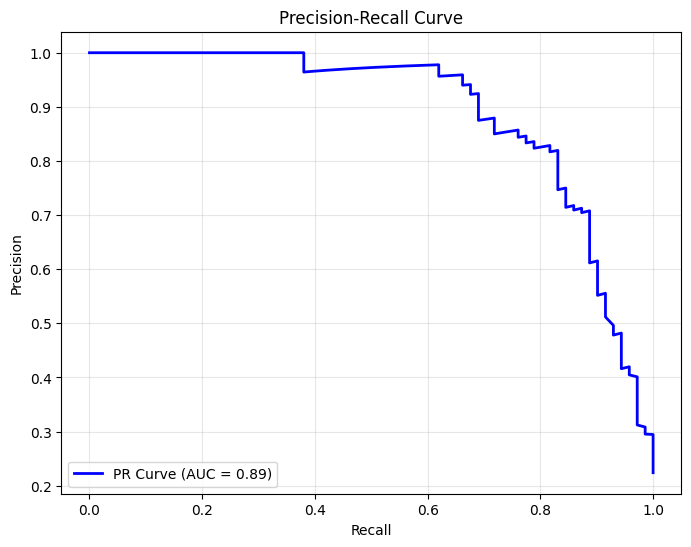

In [54]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# 1. Calculate precision and recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recalls, precisions)

# 2. Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color='blue', lw=2, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

In [59]:
from sklearn.metrics import fbeta_score
# Option A: Maximize F1 Score (Harmonic mean, balanced)
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-8)
best_idx_f1 = np.argmax(f1_scores)
best_threshold_f1 = thresholds[best_idx_f1]

# Option B: Maximize F2 Score (Prioritizes Recall)
beta = 2
f2_scores = ((1 + beta**2) * precisions * recalls) / ((beta**2 * precisions) + recalls + 1e-8)
best_idx_f2 = np.argmax(f2_scores)
best_threshold_f2 = thresholds[best_idx_f2]

print(f"Best threshold for F1-Score: {best_threshold_f1:.4f}")
print(f"Best threshold for F2-Score: {best_threshold_f2:.4f}")

# Option B: Maximize F1.5 Score (Prioritizes Recall while preserving Precision)
beta = 1.5
f2_scores = ((1 + beta**2) * precisions * recalls) / ((beta**2 * precisions) + recalls + 1e-8)
best_idx_f2 = np.argmax(f2_scores)
threshold_fbeta = thresholds[best_idx_f2]
print(threshold_fbeta)

Best threshold for F1-Score: 0.0318
Best threshold for F2-Score: 0.0446
0.0318100452514828


In [52]:
import joblib
import json

if campus == 0:
  joblib.dump(ensemble_model, 'ensemble_model_beirut.pkl')
else:
  joblib.dump(ensemble_model, 'ensemble_model_byblos.pkl')

#json_filename = 'optimal_threshold.json'
#config_data = {
#        "optimal_threshold": float(optimal_threshold), # Cast to float to ensure JSON serializability
#        "optimization_metric": "F1.5-Score",
#        "beta_value": 1.5,
#        "export_date": datetime.now().isoformat()
#    }
#with open("threshold", 'w') as json_file:
#        json.dump(config_data, json_file, indent=4)
#    print(f"Configuration saved to {json_filename}")

['ensemble_model.pkl']